In [9]:
from collections import Counter
from functools import reduce
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from rdkit.Chem import PandasTools
from rdkit.Chem.AllChem import EmbedMolecule
from rdkit.Chem.rdchem import Mol
from rdkit.Chem.rdmolfiles import (
    MolFromMolFile,
    MolFromSmiles,
    MolToMolFile,
    SDMolSupplier,
    SDWriter,
)
from rdkit.Chem.rdmolops import AddHs, CombineMols, SanitizeMol
from rdkit.Chem.rdShapeHelpers import EncodeShape, ShapeProtrudeDist
from rdkit.Geometry.rdGeometry import Point3D, UniformGrid3D
from rdkit.rdBase import DisableLog
from tqdm import tqdm

In [2]:
tqdm.pandas()

In [3]:
def add_hs(mol: Mol) -> Mol:
    try:
        assert mol is not None
        SanitizeMol(mol)
        AddHs(mol)
    except:
        return None
    return mol

In [4]:
file = "/homes/buttensc/Projects/semla-flow/data/unconditional/geom-drugs/train.sdf"
supplier = SDMolSupplier(file, sanitize=True, removeHs=False)
DisableLog("rdApp.*")
df = pd.DataFrame({"mol": [add_hs(mol) for mol in tqdm(supplier) if mol is not None]})
print(f"Loaded {len(df)} molecules")

100%|██████████| 240988/240988 [01:05<00:00, 3699.62it/s]


Loaded 240988 molecules


In [5]:
df["num_heavy"] = df["mol"].apply(lambda mol: mol.GetNumHeavyAtoms())
df["num_total"] = df["mol"].apply(lambda mol: mol.GetNumAtoms())

In [15]:
df["atom_types"] = df["mol"].progress_apply(
    lambda mol: Counter(atom.GetSymbol() for atom in mol.GetAtoms())
)

In [17]:
# combine Counters in atom types
counters = df["atom_types"].tolist()
reduce(lambda x, y: x + y, counters)

Counter({'H': 4645814,
         'C': 4315755,
         'O': 695840,
         'N': 693833,
         'S': 131513,
         'F': 52881,
         'Cl': 44036,
         'Br': 11665,
         'P': 1127,
         'I': 211,
         'B': 13,
         'Si': 10,
         'Bi': 2})

In [6]:
# get box dimensions large enough to enclose ALL molecules
mols = MolFromMolFile("data/conditional_xchem/mpro_active_site_combined.sdf")
pos_all = [mol.GetConformer().GetPositions() for mol in df["mol"]]
pos_all += [mols.GetConformer().GetPositions()]

left_bottom = np.array([p.min(axis=0) for p in pos_all]).min(axis=0)
right_top = np.array([p.max(axis=0) for p in pos_all]).max(axis=0)
print(np.stack([left_bottom, right_top]))
right_top -= left_bottom


[[-13.1894  -8.9775  -6.0225]
 [ 14.633   10.419   28.702 ]]


In [7]:
# calculate all volumes on the same grid
# reference: https://github.com/rdkit/rdkit/blob/41a2a79fa87c4f265cd22589fc226f382d380827/Code/GraphMol/ShapeHelpers/ShapeUtils.cpp#L144
def calculate_volume(mol):
    # create empty grid
    grid = UniformGrid3D(*right_top, offSet=Point3D(*left_bottom))

    # encode molecule shape
    EncodeShape(mol, grid, ignoreHs=False)

    # create occupany vector
    vector = grid.GetOccupancyVect()

    # calculate volume
    volume = vector.GetTotalVal()

    return volume

In [8]:
df["volume"] = df["mol"].progress_apply(calculate_volume)

100%|██████████| 240988/240988 [00:46<00:00, 5203.06it/s]


In [9]:
mols = mol_mols

In [10]:
vol_mols = calculate_volume(mols)
print(vol_mols)

26503


Text(0.5, 0, 'Volume')

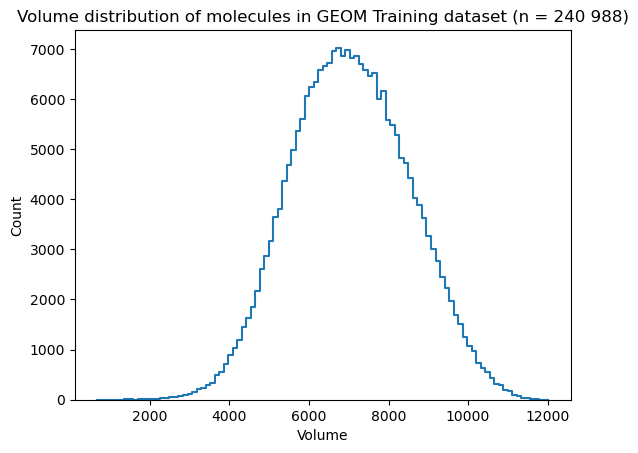

In [11]:
fig = sns.histplot(
    df, x="volume", log_scale=False, element="step", fill=False, bins=100
)
fig.set_title("Volume distribution of molecules in GEOM Training dataset (n = 240 988)")
fig.set_xlabel("Volume")

Text(0, 0.5, 'Volume')

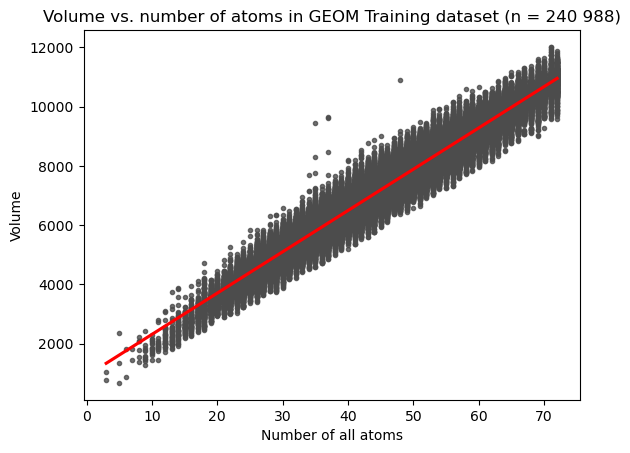

In [12]:
fig = sns.regplot(
    data=df,
    x="num_total",
    y="volume",
    order=1,
    ci=80,
    marker=".",
    color=".3",
    line_kws=dict(color="r"),
)
fig.set_title("Volume vs. number of atoms in GEOM Training dataset (n = 240 988)")
fig.set_xlabel("Number of all atoms")
fig.set_ylabel("Volume")


Text(0.5, 0, 'Volume')

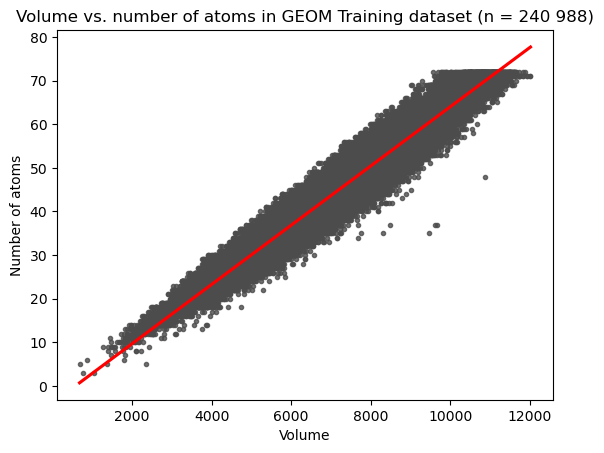

In [81]:
fig = sns.regplot(
    data=df,
    y="num_total",
    x="volume",
    order=1,
    ci=80,
    marker=".",
    color=".3",
    line_kws=dict(color="r"),
)
fig.set_title("Volume vs. number of atoms in GEOM Training dataset (n = 240 988)")
fig.set_ylabel("Number of atoms")
fig.set_xlabel("Volume")


In [14]:
model = sm.OLS(df["num_total"], df[["volume"]])
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:              num_total   R-squared (uncentered):                   0.997
Model:                            OLS   Adj. R-squared (uncentered):              0.997
Method:                 Least Squares   F-statistic:                          7.581e+07
Date:                Sat, 11 Jan 2025   Prob (F-statistic):                        0.00
Time:                        22:57:21   Log-Likelihood:                     -5.6677e+05
No. Observations:              240988   AIC:                                  1.134e+06
Df Residuals:                  240987   BIC:                                  1.134e+06
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
volume         0.0063   7.19e-07   8706.718      0.000       0.006       0.006
==============================================================================
Omnibus:                     1930.327   Durbin-Watson:                   0.744
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2271.171
Skew:                           0.162   Prob(JB):                         0.00
Kurtosis:                       3.348   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [64]:
from functools import reduce
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from rdkit.Chem import PandasTools
from rdkit.Chem.AllChem import EmbedMolecule
from rdkit.Chem.rdmolfiles import (
    MolFromMolFile,
    MolFromSmiles,
    MolToMolFile,
    SDMolSupplier,
    SDWriter,
)
from rdkit.Chem.rdmolops import CombineMols
from rdkit.Chem.rdShapeHelpers import EncodeShape, ShapeProtrudeDist
from rdkit.Geometry.rdGeometry import Point3D, UniformGrid3D
from rdkit.rdBase import DisableLog
from tqdm import tqdm

In [65]:
file = "/homes/buttensc/Projects/semla-flow/data/conditional_xchem/mpro_active_site_fragments_separate.sdf"
# file = "/homes/buttensc/Projects/semla-flow/data/conditional_xchem/mpro_active_site_separate.sdf"
supplier = SDMolSupplier(file, sanitize=False, removeHs=False)
mols_active_site = [
    add_hs(mol)
    for mol in tqdm(supplier)
    if mol is not None and mol.GetNumHeavyAtoms() <= 30
]

100%|██████████| 27/27 [00:00<00:00, 4038.88it/s]


In [66]:
# m = 30.0
# left_bottom = np.array([-m] * 3)
# right_top = np.array([m] * 3)
# right_top -= left_bottom

In [67]:
# def get_occupancy_vector(mol):
#     grid = UniformGrid3D(*right_top, offSet=Point3D(*left_bottom))
#     EncodeShape(mol, grid, ignoreHs=False)
#     vector = grid.GetOccupancyVect()
#     return np.array(vector)

# np.array([get_occupancy_vector(mol) for mol in tqdm(frags)]).max(axis=0).sum()

# max(calculate_volume(m) for m in frags)

# calculate_volume(mol_frags)

In [68]:
mols_all = np.array(mols_active_site)
n = len(mols_all)

np.random.seed(42)
rng = np.random.default_rng()

samples = []
volumes = []
num_frags = []
indices = []
choices = set()
for m in tqdm(range(1, 25)):
    list_of_indices = list(combinations(range(n), m))
    if len(list_of_indices) > 1000:
        list_of_indices = rng.choice(list_of_indices, 1000, replace=False)

    # binary_vector = np.random.randint(0, 2, size=n).astype(bool)
    # index = tuple(sorted(rng.choice(n, m, replace=False)))

    for index in list_of_indices:
        frags_filtered = mols_all[np.array(index)]
        frags_combined = reduce(CombineMols, frags_filtered)
        volume = calculate_volume(frags_combined)
        volumes.append(volume)
        num_frags.append(m)
        indices.append(index)

100%|██████████| 24/24 [02:08<00:00,  5.34s/it]


In [69]:
df_comb = pd.DataFrame({"num_frags": num_frags, "volume": volumes, "indices": indices})
df_comb["num_total_exp"] = df_comb["volume"].apply(
    lambda x: round(results.predict(x)[0])
)

<Axes: xlabel='num_frags', ylabel='volume'>

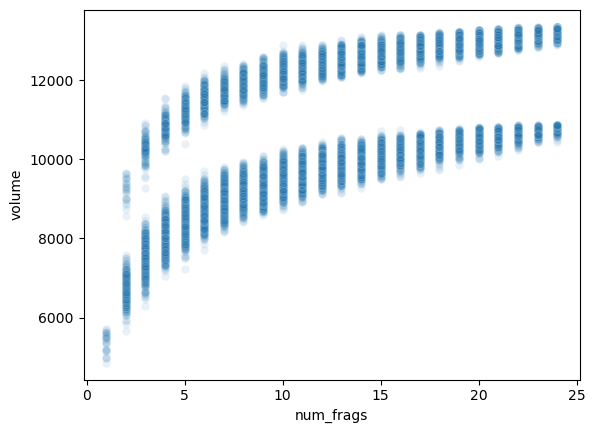

In [70]:
sns.scatterplot(data=df_comb, x="num_frags", y="volume", alpha=0.1)

<Axes: xlabel='num_frags', ylabel='num_total_exp'>

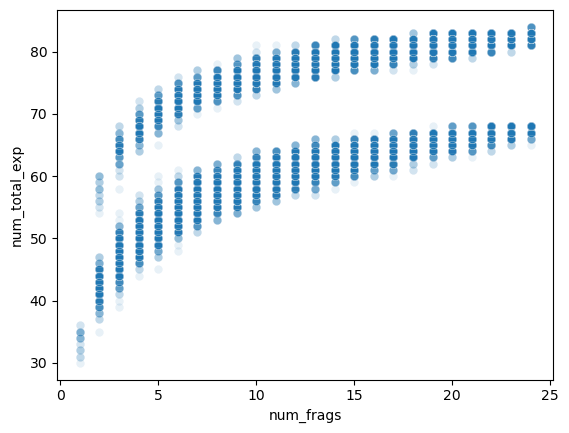

In [71]:
sns.scatterplot(data=df_comb, x="num_frags", y="num_total_exp", alpha=0.1)

In [72]:
def combine_frags(index):
    frags_filtered = mols_all[np.array(index)]
    frags_combined = reduce(CombineMols, frags_filtered)
    return frags_combined

In [73]:
# df_sel = df_comb[(df_comb.volume > 4000) & (df_comb.volume < 11000)].copy()
# df_sel["num_heavy"] = df_sel["mol_combined"].apply(lambda mol: mol.GetNumHeavyAtoms())

df_sel = df_comb[
    (df_comb.num_total_exp >= 20)
    & (df_comb.num_frags >= 3)  # & (df_comb.num_frags < 23)
]

In [74]:
df_sel.groupby("num_total_exp").size()

num_total_exp
39       1
40       1
41       3
42      11
43      17
44      59
45     116
46     168
47     223
48     262
49     282
50     307
51     345
52     345
53     409
54     418
55     471
56     526
57     578
58     585
59     614
60     654
61     738
62     710
63     711
64     719
65     711
66     623
67     464
68     233
69      69
70      88
71      96
72     157
73     188
74     280
75     333
76     431
77     517
78     715
79     970
80    1282
81    1703
82    2027
83    1826
84      14
dtype: int64

In [75]:
df_sel.groupby("num_frags").size()

num_frags
3     1000
4     1000
5     1000
6     1000
7     1000
8     1000
9     1000
10    1000
11    1000
12    1000
13    1000
14    1000
15    1000
16    1000
17    1000
18    1000
19    1000
20    1000
21    1000
22    1000
23    1000
24    1000
dtype: int64

In [76]:
# df_sel = df_sel[df_sel.num_frags < 13]
# select first 10 rows per num_frags
df_sel = df_sel.groupby("num_total_exp").head(10).reset_index(drop=True)

In [77]:
df_sel[["num_frags", "volume", "num_total_exp"]]

,num_frags,volume,num_total_exp
0,3,7831,49
1,3,7500,47
2,3,7998,50
3,3,7425,46
4,3,8089,51
...,...,...,...
430,24,13343,84
431,24,13338,84
432,24,13346,84
433,24,13339,84


In [78]:
df_sel["mol_combined"] = df_sel["indices"].apply(combine_frags)

In [79]:
df_sel

,num_frags,volume,indices,num_total_exp,mol_combined
0,3,7831,"[3, 5, 8]",49,<rdkit.Chem.rdchem.Mol object at 0x7fdec8dcdc40>
1,3,7500,"[1, 4, 8]",47,<rdkit.Chem.rdchem.Mol object at 0x7fdec8dce180>
2,3,7998,"[1, 16, 23]",50,<rdkit.Chem.rdchem.Mol object at 0x7fdec8dce420>
3,3,7425,"[14, 17, 26]",46,<rdkit.Chem.rdchem.Mol object at 0x7fdec8dce0a0>
4,3,8089,"[2, 16, 17]",51,<rdkit.Chem.rdchem.Mol object at 0x7fdec8dcdd90>
...,...,...,...,...,...
430,24,13343,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14...",84,<rdkit.Chem.rdchem.Mol object at 0x7fdee7be4d60>
431,24,13338,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 14, 15...",84,<rdkit.Chem.rdchem.Mol object at 0x7fdee7be4dd0>
432,24,13346,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",84,<rdkit.Chem.rdchem.Mol object at 0x7fdee7be4e40>
433,24,13339,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15...",84,<rdkit.Chem.rdchem.Mol object at 0x7fdee7be4eb0>


In [80]:
writer = SDWriter("data/conditional_xchem/mpro_active_site_fragments_subsampled.sdf")
for row in tqdm(df_sel.iterrows()):
    mol = row[1]["mol_combined"]
    num_frags = row[1]["num_frags"]
    num_total_exp = row[1]["num_total_exp"]
    volume = row[1]["volume"]
    mol.SetProp("_Name", f"num_frags_{num_frags}_num_total_exp_{num_total_exp}")
    mol.SetProp("num_frags", str(num_frags))
    mol.SetProp("num_total_exp", str(num_total_exp))
    mol.SetProp("volume", str(volume))
    writer.write(mol)

0it [00:00, ?it/s]

435it [00:00, 1406.81it/s]
